Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berhasil memuat file: insurance.csv
Mengambil variabel BMI sebagai input dan Charges sebagai target...
Melakukan normalisasi data...
Memulai proses training menggunakan SGD...
Epoch 0, MSE: 0.9763
Epoch 10, MSE: 0.9626
Epoch 20, MSE: 0.9626
Epoch 30, MSE: 0.9626
Epoch 40, MSE: 0.9626
Epoch 50, MSE: 0.9626
Epoch 60, MSE: 0.9626
Epoch 70, MSE: 0.9626
Epoch 80, MSE: 0.9626
Epoch 90, MSE: 0.9626
Training selesai!
Menampilkan grafik MSE dan hasil regresi...


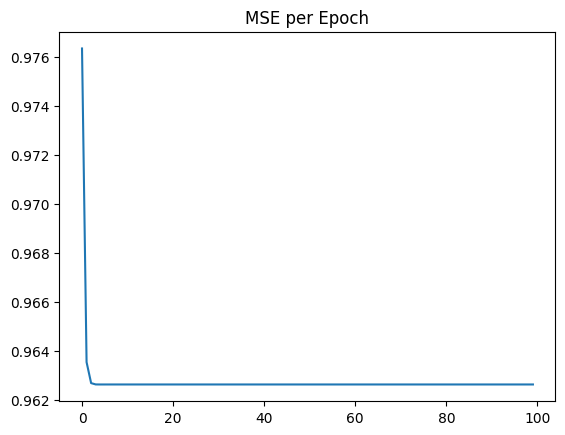

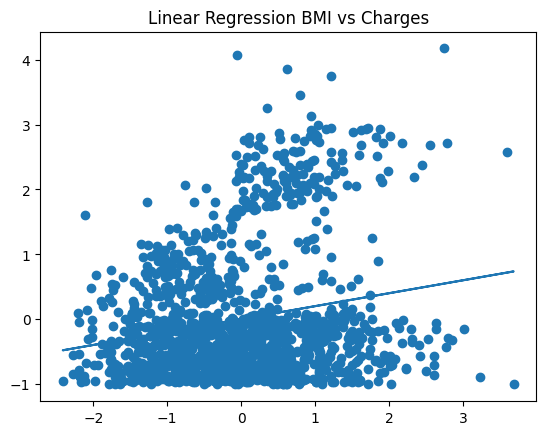

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Berhasil memuat file: insurance.csv")

df = pd.read_csv('/content/drive/MyDrive/dataset_collab/insurance.csv')

print("Mengambil variabel BMI sebagai input dan Charges sebagai target...")
x = df['bmi'].values
y = df['charges'].values

print("Melakukan normalisasi data...")
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

w = 0.0
b = 0.0
learning_rate = 0.001
epochs = 100
n = len(x)

print("Memulai proses training menggunakan SGD...")

loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for i in range(n):
        xi = x[i]
        yi = y[i]

        y_pred = w * xi + b
        error = y_pred - yi

        w = w - learning_rate * error * xi
        b = b - learning_rate * error

        total_loss += error**2

    mse = total_loss / n
    loss_history.append(mse)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, MSE: {mse:.4f}")

print("Training selesai!")
print("Menampilkan grafik MSE dan hasil regresi...")

# Grafik loss
plt.plot(loss_history)
plt.title("MSE per Epoch")
plt.show()

# Grafik regresi
y_pred_all = w * x + b
plt.scatter(x, y)
plt.plot(x, y_pred_all)
plt.title("Linear Regression BMI vs Charges")
plt.show()